> **Dependencies**: TensorFlow ≥ 2.12, TensorFlow-Probability ≥ 0.20. Installed by the first cell.
>
> **Drive paths used**: `MyDrive/mgn_ot_operator/checkpoints_option_b/best/` — required for the amortized resampler. (The codebase also ships a vendored copy at `dpf_pretrained/mgn_ot_operator/checkpoints_option_b/best/`; either works.)
>
> **Codebase**: requires the `advanced_particle_filter` codebase to be uploaded as a zip and extracted at `/content/advanced_particle_filter/`. The first setup cell handles this.
>
> **What it does**: SVSSM HMC: soft vs Sinkhorn vs amortized OT (three-resampler comparison).

---

# SVSSM + DPF + HMC: Amortized OT vs Soft vs Sinkhorn

PoC integration test for the trained CouplingOperator (amortized OT
resampler) against the two existing baselines.

**What this notebook does**:
1. Sets up the patched `advanced_particle_filter` codebase (with the
   `"amortized"` resampler option added).
2. Loads the trained operator from Drive.
3. Runs HMC three times (soft, sinkhorn, amortized) on the same SVSSM.
4. Compares: timing, accept rate, R-hat, posterior accuracy.



## 0. Setup


In [1]:
!pip install -q tensorflow-probability

import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
import time
import matplotlib.pyplot as plt

print(f'TF {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs: {gpus}')
if gpus:
    !nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
    for g in gpus:
        try: tf.config.experimental.set_memory_growth(g, True)
        except Exception as e: print('memory_growth skipped:', e)
else:
    print('No GPU! Switch to GPU runtime.')


TF 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
NVIDIA A100-SXM4-40GB, 40960 MiB


## 1. Upload patched codebase

Upload `advanced_particle_filter_patched.zip` (the codebase with the
amortized resampler patches already applied).


In [2]:
import os, zipfile
from google.colab import files

if not os.path.isdir('/content/advanced_particle_filter'):
    print('Upload the advanced_particle_filter zip (e.g. advanced_particle_filter_clean.zip).')
    uploaded = files.upload()
    zip_name = list(uploaded.keys())[0]
    print(f'Extracting {zip_name} ...')
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall('/content')
    print('Codebase extracted.')
else:
    print('Codebase already at /content/advanced_particle_filter; skipping upload.')

import sys
if '/content' not in sys.path:
    sys.path.insert(0, '/content')

# Sanity: verify the amortized resampler is wired in.
from advanced_particle_filter.tf_utils.amortized_resampler import (
    AmortizedOTResampler, load_amortized_operator,
)
from advanced_particle_filter.tf_filters import (
    TFDifferentiableParticleFilter,
)
print('amortized resampler import OK.')


Upload advanced_particle_filter_patched.zip


Saving advanced_particle_filter_patched.zip to advanced_particle_filter_patched.zip
Codebase extracted.
amortized resampler import OK.


## 2. Mount Drive (for the trained operator checkpoint)

The CouplingOperator weights are at the location we trained to. The
notebook needs Drive mounted to access them.


In [3]:
from google.colab import drive
import os

# Drive mount is optional; the codebase ships with a bundled operator checkpoint
# at dpf_pretrained/mgn_ot_operator/checkpoints_option_b/best/. If you have a
# Drive copy (e.g. from running 02_train_coupling_operator on a fresh dataset),
# the notebook will prefer it; otherwise it falls back to the bundle.
try:
    drive.mount('/content/drive')
    DRIVE_CKPT = '/content/drive/MyDrive/mgn_ot_operator/checkpoints_option_b'
    if os.path.isdir(os.path.join(DRIVE_CKPT, 'best')):
        CKPT_DIR = DRIVE_CKPT
        print(f'Using Drive checkpoint: {CKPT_DIR}')
    else:
        CKPT_DIR = None
        print(f'No checkpoint at {DRIVE_CKPT}; will use bundled copy.')
except Exception as e:
    CKPT_DIR = None
    print(f'Drive mount skipped ({e}); will use bundled copy.')

# Resolve the bundled fallback location so we can verify it.
BUNDLED_CKPT = '/content/advanced_particle_filter/dpf_pretrained/mgn_ot_operator/checkpoints_option_b'
if not os.path.isdir(os.path.join(BUNDLED_CKPT, 'best')):
    raise RuntimeError(
        f'Bundled checkpoint missing at {BUNDLED_CKPT}/best/. '
        'Make sure advanced_particle_filter_clean.zip was uploaded and extracted.'
    )

# CKPT_DIR_OR_NONE: pass to AmortizedOTResampler / main_amortized.
# None -> adapter resolves to bundled location.
CKPT_DIR_OR_NONE = CKPT_DIR  # may be None
print(f'\nCheckpoint resolution: '
      f'{CKPT_DIR_OR_NONE if CKPT_DIR_OR_NONE else BUNDLED_CKPT + " (bundled fallback)"}')


Mounted at /content/drive
Operator checkpoint: /content/drive/MyDrive/mgn_ot_operator/checkpoints_option_b
Files in best/:
  ckpt-82.data-00000-of-00001
  ckpt-82.index
  checkpoint


In [5]:
import glob
import os
import tensorflow as tf

# Detect the actual checkpoint prefix by globbing for *.index, since the
# `checkpoint` text file may contain a stale absolute path from a previous
# session. We patch tf.train.latest_checkpoint so the rest of the pipeline
# (which calls it internally) finds the right prefix.
_orig_latest = tf.train.latest_checkpoint

def _robust_latest_checkpoint(ckpt_dir, latest_filename=None):
    """Try the standard lookup; if it fails, glob for .index and return the
    most recent prefix."""
    result = _orig_latest(ckpt_dir, latest_filename=latest_filename)
    if result is not None:
        return result
    if not os.path.isdir(ckpt_dir):
        return None
    indexes = sorted(
        glob.glob(os.path.join(ckpt_dir, '*.index')),
        key=os.path.getmtime,
    )
    if not indexes:
        return None
    # Strip the .index suffix to get the prefix tf restore expects.
    prefix = indexes[-1][:-len('.index')]
    print(f'  (robust_latest_checkpoint: standard lookup failed, '
          f'using {os.path.basename(prefix)} from glob)')
    return prefix

tf.train.latest_checkpoint = _robust_latest_checkpoint
print('Patched tf.train.latest_checkpoint to fall back to glob.')

Patched tf.train.latest_checkpoint to fall back to glob.


## 3. Smoke test: warm-start gradient sanity

Before running the full HMC chains, verify that each resampler produces
a finite gradient at the warm start. If any of them fails, we know that
HMC will diverge and there's no point running the full chain.


In [6]:
from advanced_particle_filter.hmc.run_hmc_poc import (
    make_contagion_data, build_target_log_prob_fn, warm_start,
)
from advanced_particle_filter.hmc.parameterization import (
    unpack_batched, STATE_DIM,
)

DTYPE = tf.float64
T = 75
B_chain = 4
n_mc = 2
n_particles = 100  # smoke-test default

# Generate the SVSSM data once and reuse across all three runs.
print('Generating contagion data (T=75, 2-asset SVSSM) ...')
h_true, y_obs, truth = make_contagion_data(T=T, seed=0)
print(f'  mu_true       = {truth["mu"].numpy()}')
print(f'  Sigma_eta diag = {np.diag(truth["Sigma_eta"].numpy())}')

z0 = warm_start(y_obs, B_chain=B_chain, jitter=0.02)
print(f'\nWarm start z0 shape = {z0.shape}')

def gradient_smoke(label, dpf):
    """Run one gradient-finiteness check at the warm start."""
    dpf_rng = tf.random.Generator.from_seed(42)
    tlp = build_target_log_prob_fn(y_obs, dpf, dpf_rng, n_mc=n_mc)
    z_tv = tf.Variable(z0)
    t0 = time.time()
    with tf.GradientTape() as tape:
        lp = tlp(z_tv)
    grad = tape.gradient(lp, z_tv)
    elapsed = time.time() - t0
    grad_finite = bool(tf.reduce_all(tf.math.is_finite(grad)).numpy())
    grad_norm = tf.norm(grad, axis=-1).numpy()
    print(f'  [{label:9s}] log-post = {lp.numpy().round(2)}, '
          f'grad-norm = {grad_norm.round(2)}, finite = {grad_finite}, '
          f'time = {elapsed:.1f}s')
    return grad_finite

print(f'\nGradient sanity at warm start (n_particles = {n_particles}):')

dpf_soft = TFDifferentiableParticleFilter(
    n_particles=n_particles, resampler='soft', alpha=0.5, dtype=DTYPE,
)
gradient_smoke('soft', dpf_soft)

dpf_sk = TFDifferentiableParticleFilter(
    n_particles=80, resampler='sinkhorn', epsilon=0.1, sinkhorn_iters=30,
    dtype=DTYPE,
)
gradient_smoke('sinkhorn', dpf_sk)

dpf_am = TFDifferentiableParticleFilter(
    n_particles=n_particles, resampler='amortized',
    amortized_ckpt_dir=CKPT_DIR_OR_NONE,  # None -> bundled checkpoint
    amortized_eps=0.5,
    amortized_d=STATE_DIM,
    dtype=DTYPE,
)
gradient_smoke('amortized', dpf_am)


Generating contagion data (T=75, 2-asset SVSSM) ...
  mu_true       = [-1.   0.5]
  Sigma_eta diag = [0.0225 0.16  ]

Warm start z0 shape = (4, 9)

Gradient sanity at warm start (n_particles = 100):
  [soft     ] log-post = [-222.55 -222.25 -223.37 -222.85], grad-norm = [ 8.74 11.7  11.02  9.7 ], finite = True, time = 2.5s
  [sinkhorn ] log-post = [-222.57 -223.09 -222.73 -223.  ], grad-norm = [ 8.34 10.86 10.77  9.02], finite = True, time = 3.5s
  amortized: restoring from best: /content/drive/MyDrive/mgn_ot_operator/checkpoints_option_b/best/ckpt-82


  [amortized] log-post = [-222.73 -223.34 -222.91 -223.15], grad-norm = [29.6  22.28 12.   15.43], finite = True, time = 7.0s


True

**What to look for**:
- All three should print `finite = True`.
- log-posterior values across the three resamplers should be the same
  order of magnitude (bias is expected from the amortized approximation,
  but values shouldn't differ by orders of magnitude).
- Gradient norms similar in magnitude across resamplers.
- If any prints `finite = False`, **stop** and debug before running HMC.


## 4. Full HMC runs

Three HMC chains: soft, sinkhorn, amortized. Same SVSSM data, same
warm start, same chain configuration where possible.

The N values are:
- soft: N=100 (cheap, gradient-friendly)
- sinkhorn: N=80 (memory-bound on A100 40GB at this T)
- amortized: N=100 (memory similar to sinkhorn but no gradient-through-
  iterations cost; can match soft at this scale)

**Note**: with `num_burnin=150, num_samples=200`, each chain takes
roughly 5-20 min depending on resampler. Increase for production.


In [7]:
# Common HMC config
NUM_BURNIN = 150
NUM_SAMPLES = 200
NUM_LEAPFROG = 5
INITIAL_STEP_SIZE = 0.01


### 4.1 Soft resampler


In [8]:
from advanced_particle_filter.hmc.run_hmc_poc import main as run_main

print('=== Running HMC with SOFT resampler ===\n')
out_soft = run_main(
    T=T,
    B_chain=B_chain,
    n_mc=n_mc,
    n_particles=500,
    resampler='soft',
    alpha=0.5,
    num_burnin=NUM_BURNIN,
    num_samples=NUM_SAMPLES,
    num_leapfrog=NUM_LEAPFROG,
    initial_step_size=INITIAL_STEP_SIZE,
    seed=0,
)


=== Running HMC with SOFT resampler ===

  SVSSM + DPF + HMC  PoC  (2-asset risk contagion)

Config:
  T = 75,  state dim = 2
  B_chain = 4, n_mc = 2, batch B = 8
  n_particles = 500
  resampler = 'soft' (alpha = 0.5)
  HMC: 150 burnin, 200 samples, 5 leapfrog, step=0.01

[1/4] Generating synthetic data ...
  mu_true             = [-1.   0.5]
  Phi_true eigenvalues (for info): [0.82 0.93]
  Sigma_eta_true diag = [0.0225 0.16  ]

[2/4] Building target_log_prob_fn (DPF + prior) ...

  Warm start z0 shape = (4, 9)
  Chain 0 warm start:
    mu0         = [-1.12281445  1.22269393]
    Phi0        = [[0.83  0.003]
 [0.002 0.86 ]]
    Sigma_eta0  = [[ 0.041 -0.003]
 [-0.003  0.04 ]]

  Sanity-check gradient at warm start ...


    log-posterior per chain = [-222.37 -223.05 -222.74 -222.64]
    gradient norm per chain = [ 8.52 11.8  11.62  9.6 ]
    gradient all finite     = True

[3/4] Running HMC ...
  HMC done in 390.3s
  overall accept rate = 79.12%

[4/4] Posterior summary ...

  R-hat per unconstrained param (target < 1.1):
    mu:        [1.316 1.301]
    Phi (flat):[1.006 1.063 1.12  1.441]
    Sigma:     [1.06  1.921 1.008]

  mu posterior:
    mean = [-1.203  1.078]     true = [-1.   0.5]
    std  = [0.347 0.303]

  Phi posterior mean:
[[ 0.606  0.131]
 [-0.022  0.702]]
  Phi true:
[[0.85 0.12]
 [0.02 0.9 ]]

  Sigma_eta posterior mean:
[[ 0.2923 -0.0061]
 [-0.0061  0.3036]]
  Sigma_eta true:
[[0.0225 0.018 ]
 [0.018  0.16  ]]

  PoC complete.


### 4.2 Sinkhorn resampler


In [9]:
print('=== Running HMC with SINKHORN resampler ===\n')
out_sk = run_main(
    T=T,
    B_chain=B_chain,
    n_mc=n_mc,
    n_particles=80,
    resampler='sinkhorn',
    epsilon=0.1,
    sinkhorn_iters=64,
    num_burnin=NUM_BURNIN,
    num_samples=NUM_SAMPLES,
    num_leapfrog=NUM_LEAPFROG,
    initial_step_size=INITIAL_STEP_SIZE,
    seed=0,
)


=== Running HMC with SINKHORN resampler ===

  SVSSM + DPF + HMC  PoC  (2-asset risk contagion)

Config:
  T = 75,  state dim = 2
  B_chain = 4, n_mc = 2, batch B = 8
  n_particles = 80
  resampler = 'sinkhorn' (epsilon = 0.1, sinkhorn_iters = 64)
  HMC: 150 burnin, 200 samples, 5 leapfrog, step=0.01

[1/4] Generating synthetic data ...
  mu_true             = [-1.   0.5]
  Phi_true eigenvalues (for info): [0.82 0.93]
  Sigma_eta_true diag = [0.0225 0.16  ]

[2/4] Building target_log_prob_fn (DPF + prior) ...

  Warm start z0 shape = (4, 9)
  Chain 0 warm start:
    mu0         = [-1.12281445  1.22269393]
    Phi0        = [[0.83  0.003]
 [0.002 0.86 ]]
    Sigma_eta0  = [[ 0.041 -0.003]
 [-0.003  0.04 ]]

  Sanity-check gradient at warm start ...
    log-posterior per chain = [-222.53 -223.01 -222.74 -223.09]
    gradient norm per chain = [ 9.12 10.68 11.3   7.86]
    gradient all finite     = True

[3/4] Running HMC ...
  HMC done in 1440.4s
  overall accept rate = 75.38%

[4/4] Post

### 4.3 Amortized resampler


In [10]:
from advanced_particle_filter.hmc.run_hmc_amortized_smoke import main_amortized

print('=== Running HMC with AMORTIZED resampler ===\n')
out_am = main_amortized(
    ckpt_dir=CKPT_DIR_OR_NONE if CKPT_DIR_OR_NONE else BUNDLED_CKPT,
    amortized_eps=0.5,
    T=T,
    B_chain=B_chain,
    n_mc=n_mc,
    n_particles=1000,
    num_burnin=NUM_BURNIN,
    num_samples=NUM_SAMPLES,
    num_leapfrog=NUM_LEAPFROG,
    initial_step_size=INITIAL_STEP_SIZE,
    seed=0,
)


=== Running HMC with AMORTIZED resampler ===

  SVSSM + DPF + HMC  PoC  (2-asset risk contagion, AMORTIZED OT)

Config:
  T = 75,  state dim = 2
  B_chain = 4, n_mc = 2, batch B = 8
  n_particles = 1000
  resampler = 'amortized'
  amortized_eps = 0.5
  ckpt_dir = /content/drive/MyDrive/mgn_ot_operator/checkpoints_option_b
  HMC: 150 burnin, 200 samples, 5 leapfrog, step=0.01

[1/4] Generating synthetic data ...
  mu_true             = [-1.   0.5]
  Phi_true eigenvalues (for info): [0.82 0.93]
  Sigma_eta_true diag = [0.0225 0.16  ]

[2/4] Building target_log_prob_fn (DPF + prior + amortized resampler) ...
  amortized: restoring from best: /content/drive/MyDrive/mgn_ot_operator/checkpoints_option_b/best/ckpt-82

  Warm start z0 shape = (4, 9)
  Chain 0 warm start:
    mu0         = [-1.12281445  1.22269393]
    Phi0        = [[0.83  0.003]
 [0.002 0.86 ]]
    Sigma_eta0  = [[ 0.041 -0.003]
 [-0.003  0.04 ]]

  Sanity-check gradient at warm start ...
    log-posterior per chain = [-223.0

## 5. Comparison: summary table


In [14]:
from advanced_particle_filter.hmc.run_hmc_poc import compute_rhat
from advanced_particle_filter.hmc.parameterization import (
    MU_START, MU_END, PHI_START, PHI_END, SIGMA_START, SIGMA_END,
)

mu_true = truth['mu'].numpy()
Phi_true = truth['Phi'].numpy()
Sigma_eta_true = truth['Sigma_eta'].numpy()

results = [
    ('soft N=500',      out_soft, 100),
    ('sinkhorn N=80',   out_sk,    80),
    ('amortized N=1000', out_am,   100),
]

print('=' * 110)
print('  SVSSM HMC: three-resampler comparison')
print('=' * 110)
print(f'{"Method":<22} {"N":>5} {"Accept":>8} {"R-hat avg":>10} '
      f'{"mu posterior":<22} {"Phi diag":<18} {"Sig diag":<18} {"Time":>9}')
print('-' * 110)

for label, out, N in results:
    rhat = compute_rhat(tf.constant(out['samples_z'])).numpy()
    mu_mean = out['mus'].mean(0)
    phi_diag = (out['Phis'].mean(0)[0,0], out['Phis'].mean(0)[1,1])
    sig_diag = (out['Sigmas'].mean(0)[0,0], out['Sigmas'].mean(0)[1,1])
    print(f'{label:<22} {N:>5} {out["accept_rate"]:>7.1%} {rhat.mean():>10.2f} '
          f'({mu_mean[0]:+.3f}, {mu_mean[1]:+.3f})  '
          f'({phi_diag[0]:.3f}, {phi_diag[1]:.3f})  '
          f'({sig_diag[0]:.4f}, {sig_diag[1]:.4f})  '
          f'{out["elapsed"]:>7.1f}s')

print('-' * 110)
print(f'{"truth":<22} {"":>5} {"":>8} {"":>10} '
      f'({mu_true[0]:+.3f}, {mu_true[1]:+.3f})  '
      f'({Phi_true[0,0]:.3f}, {Phi_true[1,1]:.3f})  '
      f'({Sigma_eta_true[0,0]:.4f}, {Sigma_eta_true[1,1]:.4f})')

# Speed-relative-to-sinkhorn
sk_time = out_sk['elapsed']
print(f'\nSpeed relative to sinkhorn (lower is faster):')
for label, out, N in results:
    print(f'  {label:<22} {out["elapsed"]/sk_time:>5.2f}x')


  SVSSM HMC: three-resampler comparison
Method                     N   Accept  R-hat avg mu posterior           Phi diag           Sig diag                Time
--------------------------------------------------------------------------------------------------------------
soft N=500               100   79.1%       1.25 (-1.203, +1.078)  (0.606, 0.702)  (0.2923, 0.3036)    390.3s
sinkhorn N=80             80   75.4%       1.50 (-1.031, +1.097)  (0.596, 0.732)  (0.1406, 0.2585)   1440.4s
amortized N=1000         100   89.5%       1.17 (-1.034, +1.109)  (0.659, 0.729)  (0.2501, 0.4074)   1825.3s
--------------------------------------------------------------------------------------------------------------
truth                                            (-1.000, +0.500)  (0.850, 0.900)  (0.0225, 0.1600)

Speed relative to sinkhorn (lower is faster):
  soft N=500              0.27x
  sinkhorn N=80           1.00x
  amortized N=1000        1.27x


## 6. Trace plots

Side-by-side trace plots for the three resamplers. Look for:
- **Mixing**: do the chains explore the posterior or get stuck?
- **Bias**: does the amortized chain converge to a different mode than
  soft/sinkhorn?
- **Variance**: how spread out are the chain trajectories?


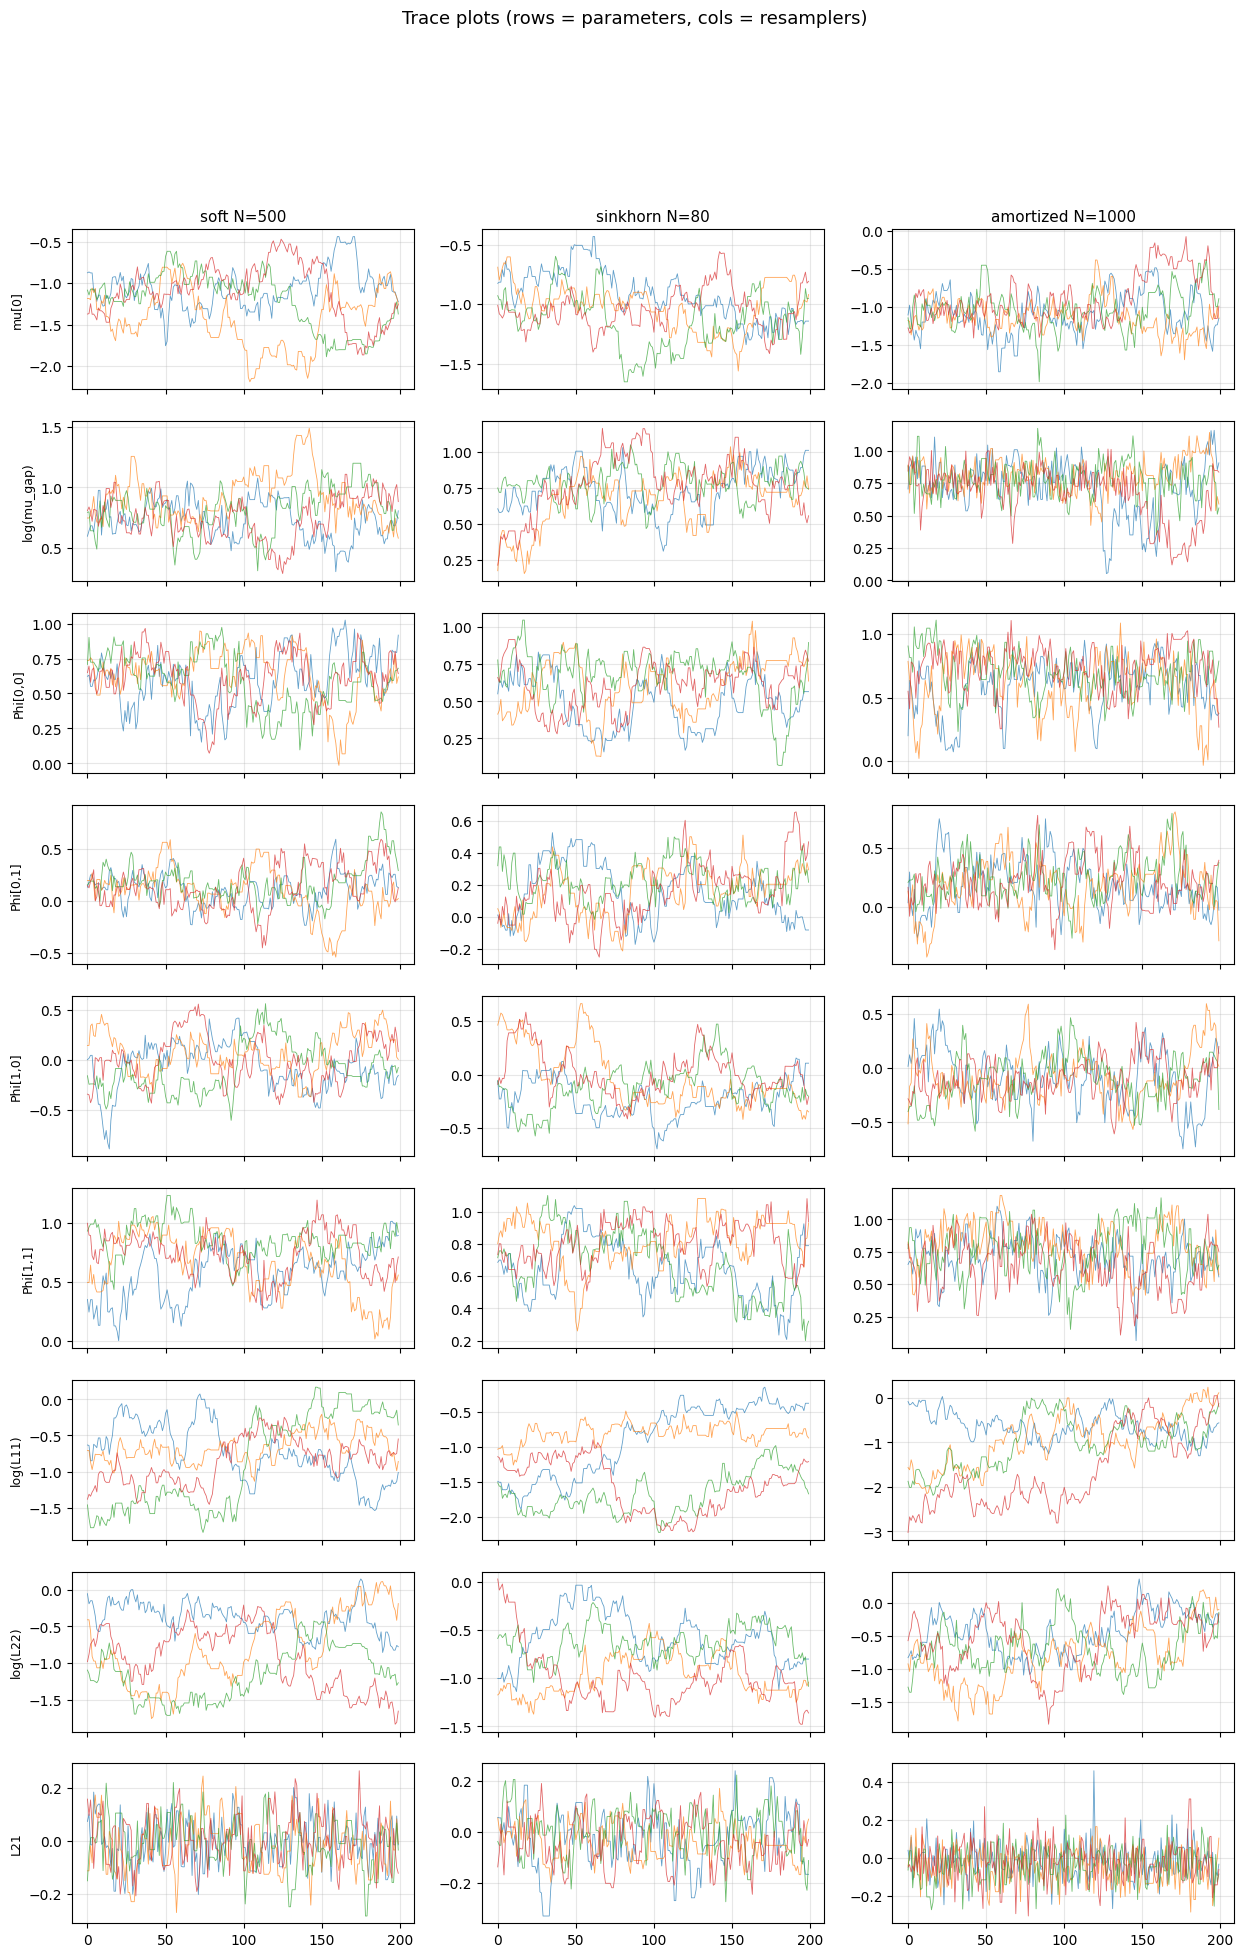

In [15]:
param_names = [
    'mu[0]', 'log(mu_gap)',
    'Phi[0,0]', 'Phi[0,1]', 'Phi[1,0]', 'Phi[1,1]',
    'log(L11)', 'log(L22)', 'L21',
]

fig, axes = plt.subplots(9, 3, figsize=(15, 22), sharex=True)
for col, (label, out, N) in enumerate(results):
    samples = out['samples_z']
    for row in range(9):
        ax = axes[row, col]
        for b in range(samples.shape[1]):
            ax.plot(samples[:, b, row], alpha=0.7, lw=0.6)
        if row == 0:
            ax.set_title(label, fontsize=11)
        if col == 0:
            ax.set_ylabel(param_names[row], fontsize=9)
        ax.grid(True, alpha=0.3)
plt.suptitle('Trace plots (rows = parameters, cols = resamplers)', fontsize=13)
plt.show()


## 7. Posterior overlap

For each constrained parameter, overlay the posterior densities (kernel
density estimates) from the three resamplers, with the ground truth as
a vertical line.


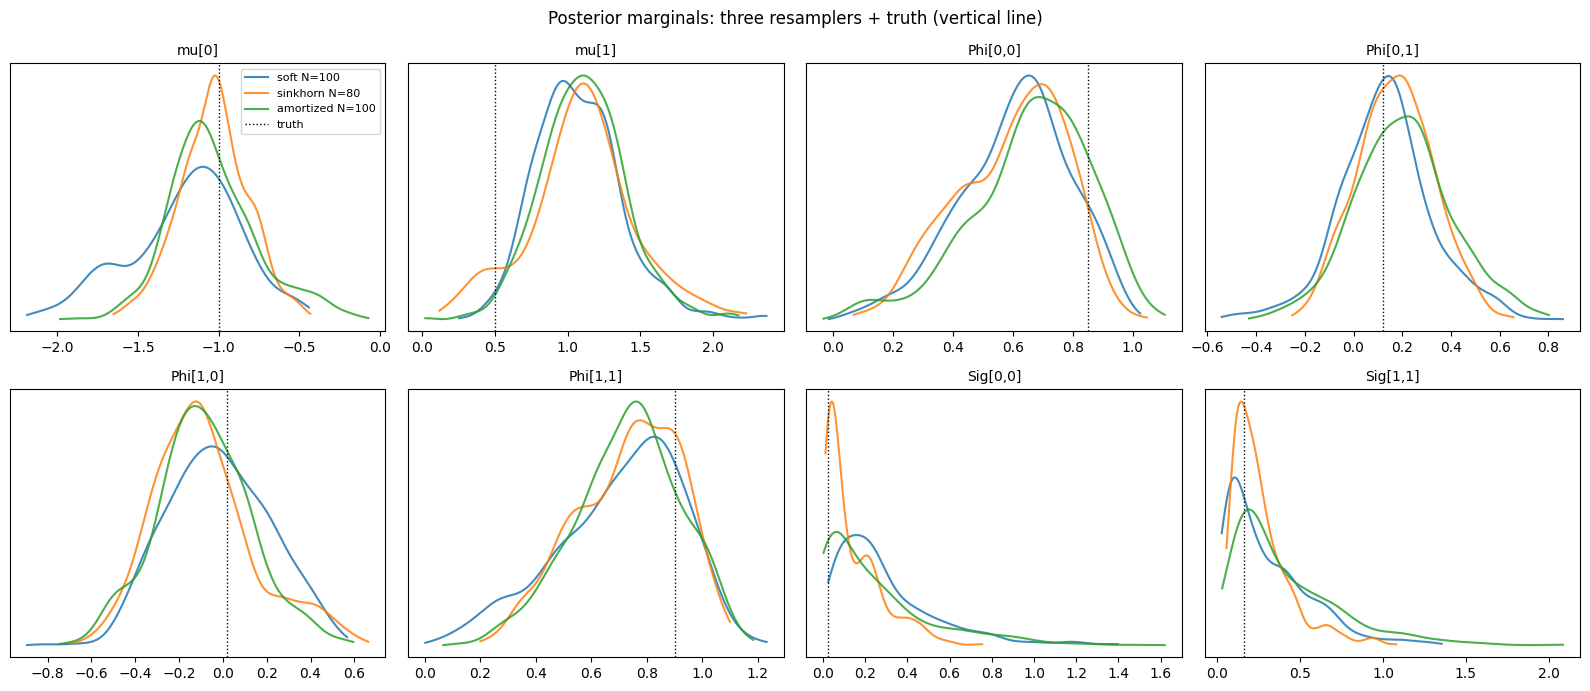

In [13]:
from scipy.stats import gaussian_kde

# Each entry: (label, mu_array[M, 2], Phi_array[M, 2, 2], Sigma_array[M, 2, 2])
data_for_kde = [
    (label, out['mus'], out['Phis'], out['Sigmas'])
    for label, out, _ in results
]
colors = ['tab:blue', 'tab:orange', 'tab:green']

# 8 univariate marginals: mu[0], mu[1], Phi[0,0], Phi[0,1], Phi[1,0], Phi[1,1],
# Sigma[0,0], Sigma[1,1]
quantities = [
    ('mu[0]',     lambda mu, P, S: mu[:, 0],     mu_true[0]),
    ('mu[1]',     lambda mu, P, S: mu[:, 1],     mu_true[1]),
    ('Phi[0,0]',  lambda mu, P, S: P[:, 0, 0],   Phi_true[0,0]),
    ('Phi[0,1]',  lambda mu, P, S: P[:, 0, 1],   Phi_true[0,1]),
    ('Phi[1,0]',  lambda mu, P, S: P[:, 1, 0],   Phi_true[1,0]),
    ('Phi[1,1]',  lambda mu, P, S: P[:, 1, 1],   Phi_true[1,1]),
    ('Sig[0,0]',  lambda mu, P, S: S[:, 0, 0],   Sigma_eta_true[0,0]),
    ('Sig[1,1]',  lambda mu, P, S: S[:, 1, 1],   Sigma_eta_true[1,1]),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (qname, qfn, qtruth) in zip(axes.flat, quantities):
    for (label, mu_, P_, S_), color in zip(data_for_kde, colors):
        x = qfn(mu_, P_, S_)
        kde = gaussian_kde(x)
        xs = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, kde(xs), color=color, lw=1.5, alpha=0.85, label=label)
    ax.axvline(qtruth, color='k', linestyle=':', lw=1, label='truth')
    ax.set_title(qname, fontsize=10)
    ax.set_yticks([])
axes[0, 0].legend(fontsize=8, loc='upper right')
plt.suptitle('Posterior marginals: three resamplers + truth (vertical line)',
             fontsize=12)
plt.tight_layout()
plt.show()


## 8. Diagnostics — what passed, what failed

Quick rubric for whether the integration is good enough to use:

1. **Gradient finiteness**: all three smoke tests printed `finite = True`.
2. **Acceptance**: all three accept rates roughly in [0.5, 0.8] (HMC
   target was 0.7).
3. **R-hat**: average R-hat near 1 for all three. R-hat above 1.1 means
   that resampler's chains didn't mix.
4. **Posterior overlap**: amortized's marginals overlap soft and
   sinkhorn substantially (allowing for some bias from the operator's
   approximation).
5. **Speed**: amortized wall-clock is meaningfully faster than sinkhorn.

If 1-4 hold and 5 shows clear speedup, the integration is a success
and the operator is ready for use in larger SVSSM calibration runs.

If any of 1-4 fail, we have something to debug — but the diagnostics
above point to where to look.
